

#### DAMG6105 Data Science Engineering with Python

Instructor: Dr. Handan Liu

#### Submission Instructions
Submit this `ipynb` file via Canvas.  To ensure that your submitted files represent your latest code, make sure to give a fresh `Kernel > Restart Kerne and Run All` just before submitting files. 

## Project 2: Sentiment Analysis of Amazon Product Customer Reviews 


### Your name: Ayushi Ghia

## Project Summary:

You will work with a messy real-world Amazon melatonin dataset spread across multiple CSV files. Your first task is to clean, organize, and merge the files into one dataframe. Then you will standardize melatonin dose values and group products by **dose rather than brand**. You will analyze the distribution of doses in the market, perform sentiment analysis using `review_rating`, and use NLP on `review_text` and `review_header` to study how customer experiences vary across doses. Focus especially on themes such as how long it takes to feel sleepy, when users take the pills, duration of use, whether they recommend the product, and side effects or reactions after taking it.


## Background

The market for melatonin products is highly chaotic, with many products sold at different dosages such as 1mg, 2mg, 3mg, 5mg, 10mg, 12mg, and 20mg. In this project, you will work with a real-world Amazon dataset containing melatonin product information and customer reviews. The dataset is messy and spread across multiple CSV files, so part of the project is to organize, clean, and merge the data before conducting analysis. The main goal is to study how customer sentiment and review language vary across **different doses**, not across brands.


## Project Objectives

You are required to complete the following tasks, including all possible visualization for each step as below:

## 1. Data Wrangling  

### 1. Integration

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

### 2. Connect files

In [67]:
# Run this to see what folder your notebook is currently in
print(os.getcwd())

/Users/ayushighia


In [12]:
DATA_DIR = os.getcwd()

file_dose_map = {
    "melatonin-amazon-1mg.xlsx": 1,
    "melatonin-amazon-3mg.xlsx": 3,
    "melatonin-amazon-5mg.xlsx": 5,
    "melatonin-amazon-Natrol-Fast-Dissolve-5mg.xlsx": 5,
    "melatonin-amazon-10mg.xlsx": 10,
    "melatonin-amazon-12mg.xlsx": 12,
    "melatonin-amazon-nature's-Truth-Melatonin-Gummies-12mg .xlsx": 12,
    "melatonin-amazon-20mg.xlsx": 20,
}

dfs = []
for filename, dose in file_dose_map.items():
    df = pd.read_excel(os.path.join(DATA_DIR, filename))
    df["dose_mg"] = dose
    dfs.append(df)
    print(f"Loaded: {filename}  →  {len(df)} rows")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows after merge: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")


Loaded: melatonin-amazon-1mg.xlsx  →  4492 rows
Loaded: melatonin-amazon-3mg.xlsx  →  1307 rows
Loaded: melatonin-amazon-5mg.xlsx  →  4478 rows
Loaded: melatonin-amazon-Natrol-Fast-Dissolve-5mg.xlsx  →  7524 rows
Loaded: melatonin-amazon-10mg.xlsx  →  7624 rows
Loaded: melatonin-amazon-12mg.xlsx  →  9554 rows
Loaded: melatonin-amazon-nature's-Truth-Melatonin-Gummies-12mg .xlsx  →  936 rows
Loaded: melatonin-amazon-20mg.xlsx  →  5336 rows

Total rows after merge: 41251
Columns: ['ASIN', 'Brand', 'HelpfulCounts', 'Images', 'PageUrl', 'ParentId', 'ProductLink', 'ProductTitle', 'ReviewContent', 'ReviewDate', 'ReviewScore', 'ReviewTitle', 'Reviewer', 'Verified', 'dose_mg']


### 3. Drop Irrelevant Columns


In [13]:
df_all = df_all.drop(columns=["Images", "PageUrl", "ProductLink"])

print("Remaining columns:")
print(df_all.columns.tolist())

Remaining columns:
['ASIN', 'Brand', 'HelpfulCounts', 'ParentId', 'ProductTitle', 'ReviewContent', 'ReviewDate', 'ReviewScore', 'ReviewTitle', 'Reviewer', 'Verified', 'dose_mg']


### 4.Handle Missing Values

In [15]:
print("Null counts before cleaning:")
print(df_all.isnull().sum())

# Drop rows with no review text — useless for NLP
df_all = df_all.dropna(subset=["ReviewContent"])

# Fill missing review titles with empty string
df_all["ReviewTitle"] = df_all["ReviewTitle"].fillna("")

print("\nNull counts after cleaning:")
print(df_all.isnull().sum())

Null counts before cleaning:
ASIN               0
Brand              0
HelpfulCounts      0
ParentId           0
ProductTitle       0
ReviewContent    393
ReviewDate         0
ReviewScore        0
ReviewTitle       71
Reviewer           4
Verified           0
dose_mg            0
dtype: int64

Null counts after cleaning:
ASIN             0
Brand            0
HelpfulCounts    0
ParentId         0
ProductTitle     0
ReviewContent    0
ReviewDate       0
ReviewScore      0
ReviewTitle      0
Reviewer         4
Verified         0
dose_mg          0
dtype: int64


### 5. Remove Duplicates

In [16]:
before = len(df_all)
df_all = df_all.drop_duplicates(subset=["ParentId", "ReviewContent"])

print(f"Rows before dedup : {before}")
print(f"Rows after dedup  : {len(df_all)}")
print(f"Duplicates removed: {before - len(df_all)}")

Rows before dedup : 40858
Rows after dedup  : 4984
Duplicates removed: 35874


### 6.Final Check

In [17]:
print(f"Final dataset shape: {df_all.shape}")
print(f"\nDose distribution:")
print(df_all["dose_mg"].value_counts().sort_index())
print(f"\nData types:")
print(df_all.dtypes)
print(f"\nSample rows:")
df_all[["Brand", "dose_mg", "ReviewScore", "ReviewTitle", "ReviewContent"]].head(5)

Final dataset shape: (4984, 12)

Dose distribution:
dose_mg
1      618
3      855
5     1257
10     674
12    1186
20     394
Name: count, dtype: int64

Data types:
ASIN              object
Brand             object
HelpfulCounts     object
ParentId          object
ProductTitle      object
ReviewContent     object
ReviewDate        object
ReviewScore      float64
ReviewTitle       object
Reviewer          object
Verified            bool
dose_mg            int64
dtype: object

Sample rows:


,Brand,dose_mg,ReviewScore,ReviewTitle,ReviewContent
0,Natrol,1,5.0,Really tasty AND effective sleep aid,"I'm 40, but have been dealing with sleep probl..."
1,Natrol,1,5.0,The best melatonin out there,Fast acting. Great tasting. No nightmares. I...
2,Natrol,1,5.0,Really helpful on those nights that sleep just...,"They dissolve easily, taste good, and are effe..."
3,Natrol,1,5.0,Love the low dose,This is great for helping me or my kiddo fall ...
4,Natrol,1,4.0,1 mg dose is highly effective,Dose provides assistance in obtaining quality ...


### 7. Visualizations

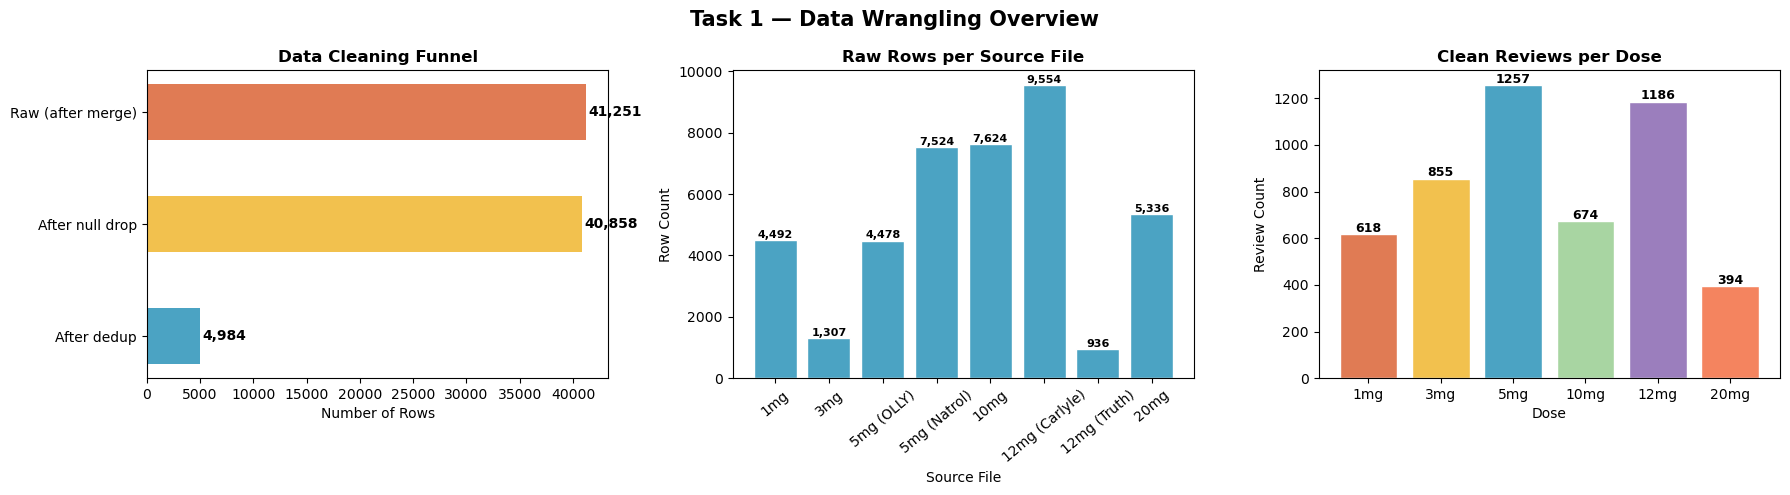

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Task 1 — Data Wrangling Overview", fontsize=15, fontweight='bold')

# Chart 1: Cleaning funnel
stages = ['Raw (after merge)', 'After null drop', 'After dedup']
counts = [41251, 40858, 4984]
axes[0].barh(stages, counts, color=['#E07B54', '#F2C14E', '#4BA3C3'], height=0.5)
axes[0].set_title("Data Cleaning Funnel", fontweight='bold')
axes[0].set_xlabel("Number of Rows")
axes[0].invert_yaxis()
for i, v in enumerate(counts):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontweight='bold')

# Chart 2: Raw rows per source file
raw_counts = {
    "1mg": 4492, "3mg": 1307, "5mg (OLLY)": 4478,
    "5mg (Natrol)": 7524, "10mg": 7624,
    "12mg (Carlyle)": 9554, "12mg (Truth)": 936, "20mg": 5336
}
axes[1].bar(raw_counts.keys(), raw_counts.values(), color='#4BA3C3', edgecolor='white')
axes[1].set_title("Raw Rows per Source File", fontweight='bold')
axes[1].set_xlabel("Source File")
axes[1].set_ylabel("Row Count")
axes[1].tick_params(axis='x', rotation=40)
for i, v in enumerate(raw_counts.values()):
    axes[1].text(i, v + 80, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

# Chart 3: Clean reviews per dose
dose_counts = df_all["dose_mg"].value_counts().sort_index()
axes[2].bar(
    [f"{d}mg" for d in dose_counts.index],
    dose_counts.values,
    color=['#E07B54', '#F2C14E', '#4BA3C3', '#A8D5A2', '#9B7EBD', '#F4845F'],
    edgecolor='white'
)
axes[2].set_title("Clean Reviews per Dose", fontweight='bold')
axes[2].set_xlabel("Dose")
axes[2].set_ylabel("Review Count")
for i, v in enumerate(dose_counts.values):
    axes[2].text(i, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 2. Data Operation and Manipulation

### 1.Extract Dose from ProductTitle & Verify

In [22]:
import re

def extract_dose(title):
    match = re.search(r'(\d+(?:\.\d+)?)\s*mg', title, re.IGNORECASE)
    return float(match.group(1)) if match else None

df_all["dose_extracted"] = df_all["ProductTitle"].apply(extract_dose)

mismatches = df_all[df_all["dose_extracted"] != df_all["dose_mg"]]
print(f"Mismatches between filename dose and title dose: {len(mismatches)}")
print(mismatches[["ProductTitle", "dose_mg", "dose_extracted"]].drop_duplicates())

Mismatches between filename dose and title dose: 0
Empty DataFrame
Columns: [ProductTitle, dose_mg, dose_extracted]
Index: []


### 2.Parse ReviewDate to Datetime

In [23]:
# Some dates have prefix e.g. "Reviewed in Mexico on October 10, 2024"
# We extract just the date part before parsing
def clean_date(d):
    match = re.search(r'([A-Za-z]+ \d+, \d{4})', str(d))
    return match.group(1) if match else d

df_all["ReviewDate"] = df_all["ReviewDate"].apply(clean_date)
df_all["ReviewDate"] = pd.to_datetime(df_all["ReviewDate"], format="%B %d, %Y")

print("ReviewDate dtype:", df_all["ReviewDate"].dtype)
print("Date range:", df_all["ReviewDate"].min(), "→", df_all["ReviewDate"].max())

ReviewDate dtype: datetime64[ns]
Date range: 2009-10-27 00:00:00 → 2024-11-15 00:00:00


### 3.Fix HelpfulCounts to Numeric

In [24]:
df_all["HelpfulCounts"] = pd.to_numeric(df_all["HelpfulCounts"], errors="coerce").fillna(0).astype(int)

print("HelpfulCounts dtype:", df_all["HelpfulCounts"].dtype)
print(df_all["HelpfulCounts"].describe())

HelpfulCounts dtype: int64
count    4984.000000
mean        2.342295
std        18.570583
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       720.000000
Name: HelpfulCounts, dtype: float64


### 4. Convert ReviewScore to Integer

In [25]:
df_all["ReviewScore"] = df_all["ReviewScore"].astype(int)

print("ReviewScore distribution:")
print(df_all["ReviewScore"].value_counts().sort_index())

ReviewScore distribution:
ReviewScore
1    1165
2     757
3     810
4     912
5    1340
Name: count, dtype: int64


### 5. Add Sentiment Label

In [28]:
def label_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df_all["sentiment"] = df_all["ReviewScore"].apply(label_sentiment)

print("Sentiment distribution:")
print(df_all["sentiment"].value_counts())

Sentiment distribution:The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

sentiment
Positive    2252
Negative    1922
Neutral      810
Name: count, dtype: int64


### 6. Add Dose Category

In [70]:
def dose_category(dose):
    if dose <=4:
        return "Low (1-4mg)"
    elif dose <= 11:
        return "Medium (5-10mg)"
    else:
        return "High (11-20mg)"

df_all["dose_category"] = df_all["dose_mg"].apply(dose_category)

print("Dose category distribution:")
print(df_all["dose_category"].value_counts())

Dose category distribution:
dose_category
Medium (5-10mg)    1931
High (11-20mg)     1580
Low (1-4mg)        1473
Name: count, dtype: int64


### 7. Visualizations

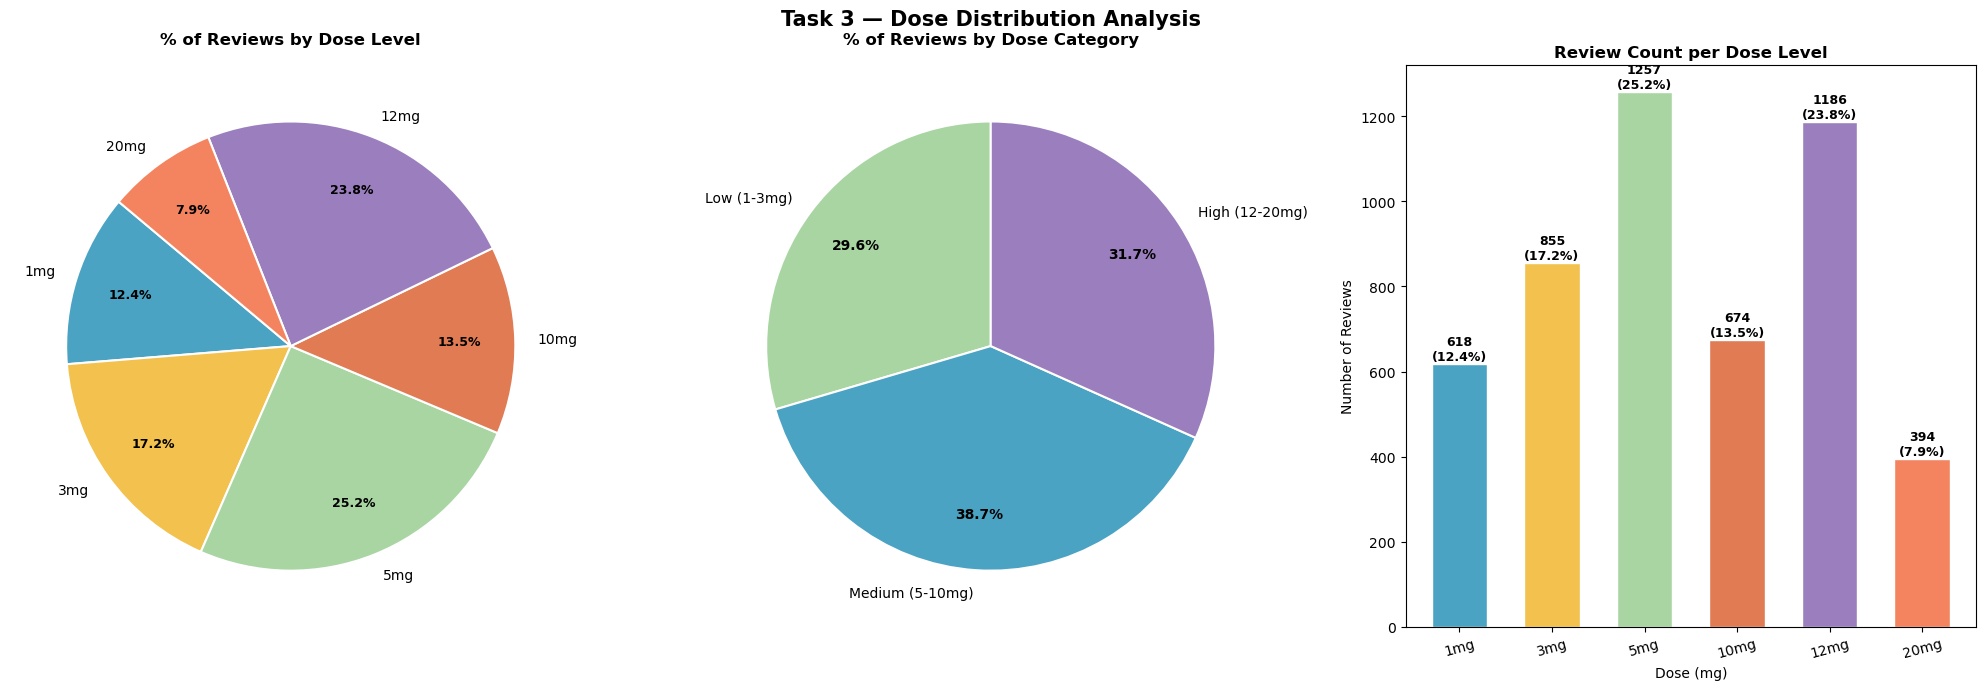

In [31]:
dose_counts = df_all["dose_mg"].value_counts().sort_index()
cat_order = ["Low (1-3mg)", "Medium (5-10mg)", "High (12-20mg)"]
cat_counts = df_all["dose_category"].value_counts().reindex(cat_order)

colors_dose = ['#4BA3C3','#F2C14E','#A8D5A2','#E07B54','#9B7EBD','#F4845F']
colors_cat  = ['#A8D5A2','#4BA3C3','#9B7EBD']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Task 3 — Dose Distribution Analysis", fontsize=15, fontweight='bold')

# Pie 1 — % of reviews per dose level
wedges, texts, autotexts = axes[0].pie(
    dose_counts.values,
    labels=[f"{d}mg" for d in dose_counts.index],
    colors=colors_dose,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[0].set_title("% of Reviews by Dose Level", fontweight='bold', pad=15)

# Pie 2 — % by dose category
wedges2, texts2, autotexts2 = axes[1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    colors=colors_cat,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.75
)
for t in autotexts2:
    t.set_fontsize(10)
    t.set_fontweight('bold')
axes[1].set_title("% of Reviews by Dose Category", fontweight='bold', pad=15)

# Histogram — review count per dose
axes[2].bar(
    [f"{d}mg" for d in dose_counts.index],
    dose_counts.values,
    color=colors_dose,
    edgecolor='white',
    width=0.6
)
axes[2].set_title("Review Count per Dose Level", fontweight='bold')
axes[2].set_xlabel("Dose (mg)")
axes[2].set_ylabel("Number of Reviews")
axes[2].tick_params(axis='x', rotation=15)
for i, (d, v) in enumerate(zip(dose_counts.index, dose_counts.values)):
    pct = v / len(df_all) * 100
    axes[2].text(i, v + 10, f'{v}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Dose Distribution Analysis

Analyze the proportion of products across dose levels.

For example:

- What percentage of products are 1mg, 3mg, 5mg, 10mg, 20mg, etc.?
- Which dosage ranges dominate the market?
- Are low-dose or high-dose products more common?
- ....
    

### 1. Compute Stats


In [32]:
dose_counts = df_all["dose_mg"].value_counts().sort_index()
cat_order = ["Low (1-3mg)", "Medium (5-10mg)", "High (12-20mg)"]
cat_counts = df_all["dose_category"].value_counts().reindex(cat_order)
avg_helpful = df_all.groupby("dose_mg")["HelpfulCounts"].mean().round(2)
verified_pct = (df_all.groupby("dose_mg")["Verified"].mean() * 100).round(1)

df_all["year"] = df_all["ReviewDate"].dt.year
yearly = df_all.groupby(["year","dose_mg"]).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2020]

print("Reviews per dose level:")
for d, v in dose_counts.items():
    print(f"  {d}mg: {v} ({v/len(df_all)*100:.1f}%)")

print("\nReviews per category:")
for c, v in cat_counts.items():
    print(f"  {c}: {v} ({v/len(df_all)*100:.1f}%)")

Reviews per dose level:
  1mg: 618 (12.4%)
  3mg: 855 (17.2%)
  5mg: 1257 (25.2%)
  10mg: 674 (13.5%)
  12mg: 1186 (23.8%)
  20mg: 394 (7.9%)

Reviews per category:
  Low (1-3mg): 1473 (29.6%)
  Medium (5-10mg): 1931 (38.7%)
  High (12-20mg): 1580 (31.7%)


### 2. Visualizations

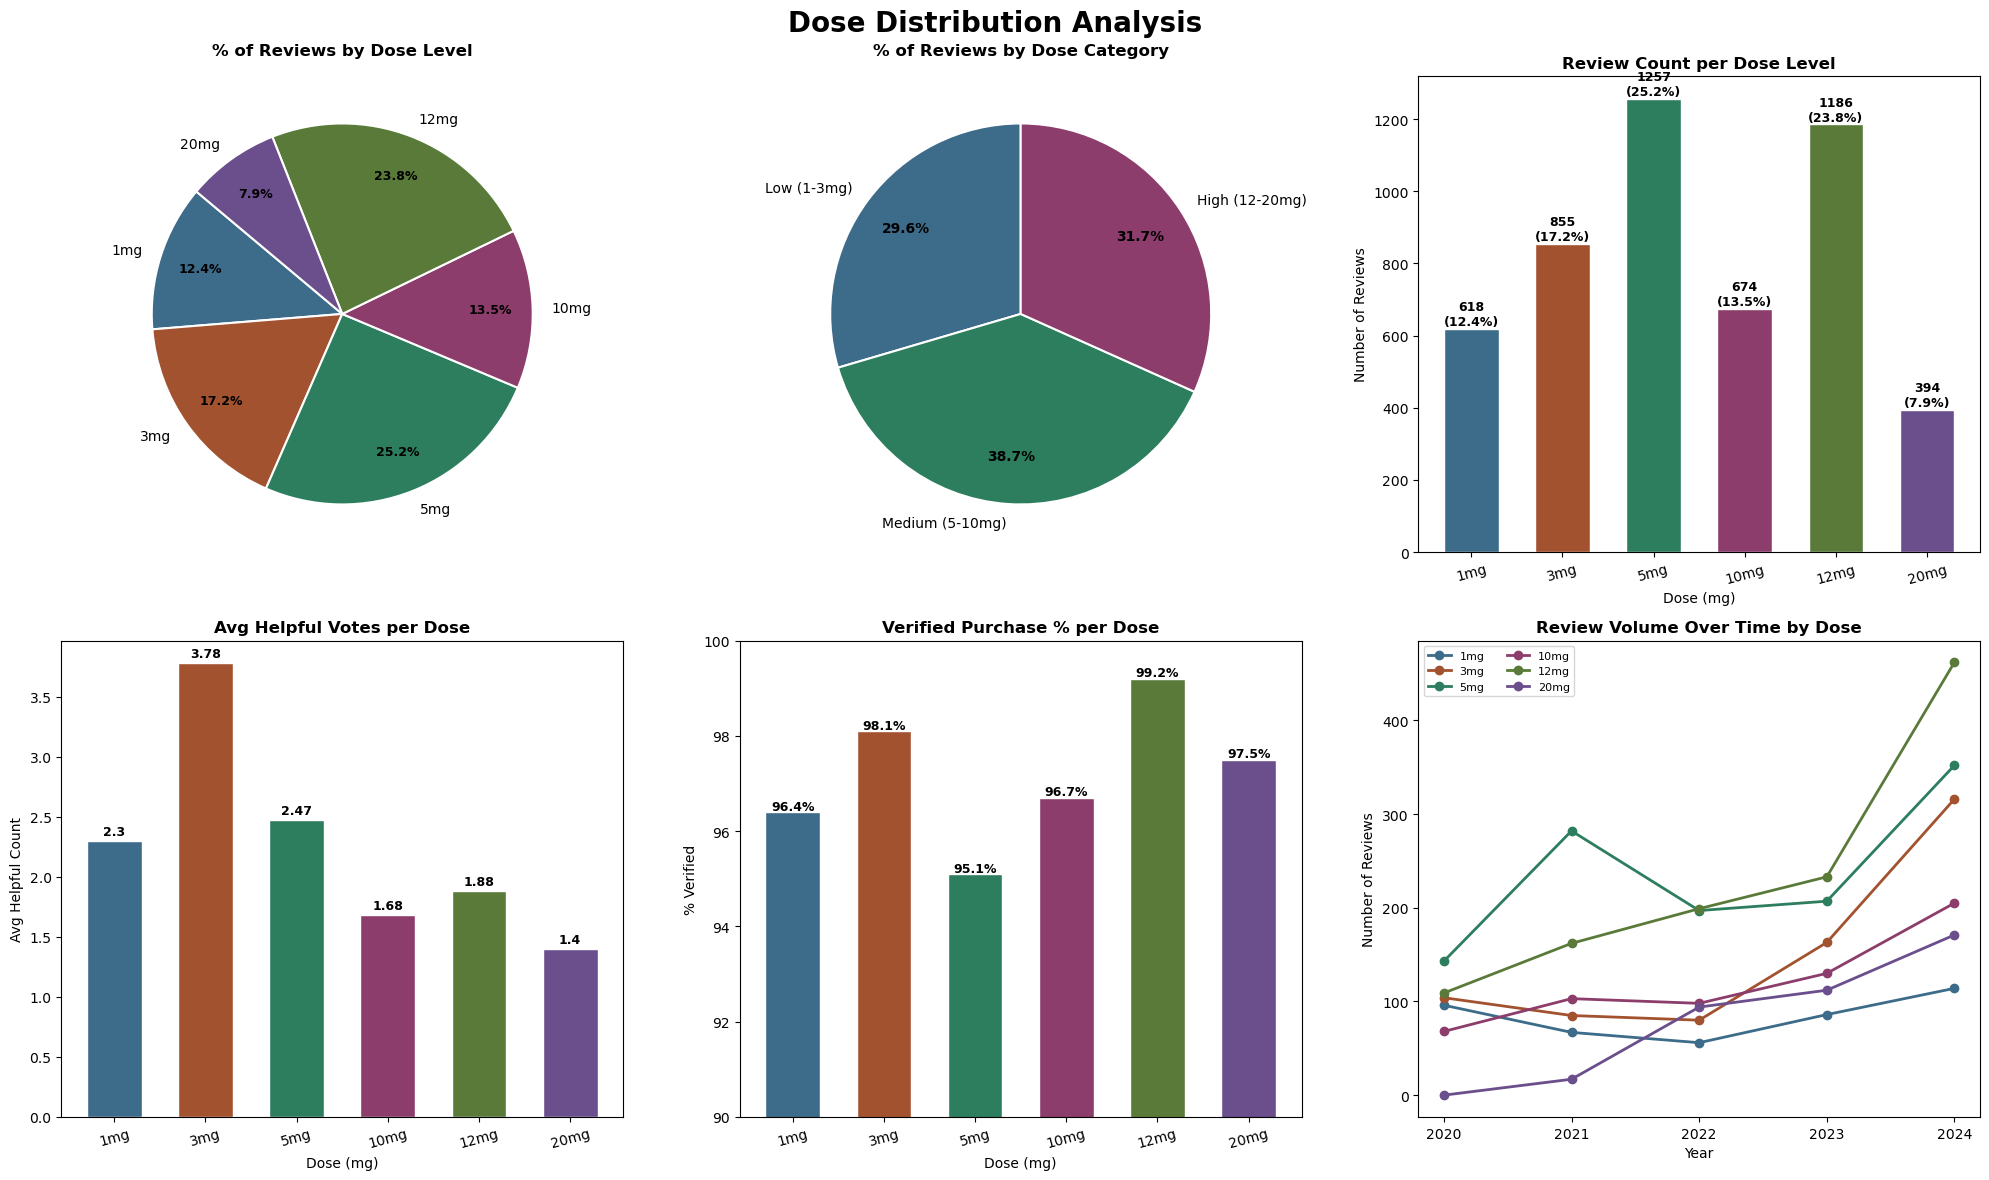

In [34]:
colors_dose = ['#3D6B8A', '#A3522F', '#2D7D5F', '#8C3D6B', '#5A7A3A', '#6B4E8C']
colors_cat  = ['#3D6B8A', '#2D7D5F', '#8C3D6B']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Dose Distribution Analysis", fontsize=20, fontweight='bold')

# Pie 1 — % by dose level
wedges, texts, autotexts = axes[0,0].pie(
    dose_counts.values,
    labels=[f"{d}mg" for d in dose_counts.index],
    colors=colors_dose, autopct='%1.1f%%', startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, pctdistance=0.78
)
for t in autotexts:
    t.set_fontsize(9); t.set_fontweight('bold')
axes[0,0].set_title("% of Reviews by Dose Level", fontweight='bold', pad=15)

# Pie 2 — % by dose category
wedges2, texts2, autotexts2 = axes[0,1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    colors=colors_cat, autopct='%1.1f%%', startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, pctdistance=0.75
)
for t in autotexts2:
    t.set_fontsize(10); t.set_fontweight('bold')
axes[0,1].set_title("% of Reviews by Dose Category", fontweight='bold', pad=15)

# Histogram — review count per dose
axes[0,2].bar(
    [f"{d}mg" for d in dose_counts.index],
    dose_counts.values,
    color=colors_dose, edgecolor='white', width=0.6
)
axes[0,2].set_title("Review Count per Dose Level", fontweight='bold')
axes[0,2].set_xlabel("Dose (mg)")
axes[0,2].set_ylabel("Number of Reviews")
axes[0,2].tick_params(axis='x', rotation=15)
for i, (d, v) in enumerate(zip(dose_counts.index, dose_counts.values)):
    pct = v / len(df_all) * 100
    axes[0,2].text(i, v + 10, f'{v}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')

# Chart 4 — Avg helpful votes per dose
axes[1,0].bar(
    [f"{d}mg" for d in avg_helpful.index],
    avg_helpful.values,
    color=colors_dose, edgecolor='white', width=0.6
)
axes[1,0].set_title("Avg Helpful Votes per Dose", fontweight='bold')
axes[1,0].set_xlabel("Dose (mg)")
axes[1,0].set_ylabel("Avg Helpful Count")
axes[1,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(avg_helpful.values):
    axes[1,0].text(i, v + 0.05, f'{v}', ha='center', fontsize=9, fontweight='bold')

# Chart 5 — Verified purchase % per dose
axes[1,1].bar(
    [f"{d}mg" for d in verified_pct.index],
    verified_pct.values,
    color=colors_dose, edgecolor='white', width=0.6
)
axes[1,1].set_title("Verified Purchase % per Dose", fontweight='bold')
axes[1,1].set_xlabel("Dose (mg)")
axes[1,1].set_ylabel("% Verified")
axes[1,1].set_ylim(90, 100)
axes[1,1].tick_params(axis='x', rotation=15)
for i, v in enumerate(verified_pct.values):
    axes[1,1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=9, fontweight='bold')

# Chart 6 — Review volume over time
for dose, color in zip(dose_counts.index, colors_dose):
    if dose in yearly.columns:
        axes[1,2].plot(yearly.index, yearly[dose], marker='o',
                       label=f"{dose}mg", color=color, linewidth=2)
axes[1,2].set_title("Review Volume Over Time by Dose", fontweight='bold')
axes[1,2].set_xlabel("Year")
axes[1,2].set_ylabel("Number of Reviews")
axes[1,2].legend(fontsize=8, ncol=2)
axes[1,2].set_xticks(yearly.index)

plt.tight_layout()
plt.show()

### Analysis from the graphs

### Market Share of the doses 

- 5mg is the most popular dose with 1,257 reviews (25.2%) — it dominates the market, likely because it strikes a balance between effectiveness and safety
- 12mg comes in second at 1,186 reviews (23.8%) — surprisingly high, suggesting demand for stronger doses is growing
- 20mg is the least common at just 394 reviews (7.9%) — a niche high-potency segment with limited adoption
3mg sits at 17.2% — popular as a moderate entry-level dose

### Dose Category Dominance

- Medium dose (5–10mg) leads the market at 38.7% of all reviews
- High dose (12–20mg) is nearly as popular as Low dose — 31.7% vs 29.6% — meaning the market is not skewed toward low doses as one might expect

This suggests consumers are increasingly comfortable with stronger melatonin products

### Review Helpfulness by Dose

- 3mg reviews are the most helpful on average (3.78 helpful votes) — suggesting buyers of moderate doses write more informative, nuanced reviews
- 20mg has the lowest helpful count (1.40) — possibly because fewer people use it, so fewer people find those reviews relatable
- 1mg reviews score second highest (2.30) — likely because users share detailed experiences about using very low doses intentionally

### Purchase Authenticity



- 12mg has the highest verified purchase rate at 99.2% — almost every review is from a confirmed buyer, making those reviews highly trustworthy

- All doses are above 95% verified — the dataset is overwhelmingly authentic across the board

### Review Growth Over Time 

- Every dose has grown in review volume year over year — the melatonin supplement market is clearly expanding
- 2024 saw the biggest spike across all doses — 5mg jumped to 352 reviews and 12mg hit 462 in a single year
- 20mg had zero reviews before 2021 — it's an entirely new market segment that emerged recently
- 3mg grew the fastest proportionally — from 104 reviews in 2020 to 316 in 2024, a 3x increase

### Overall Takeaway

The melatonin market is not dominated by low doses as conventional wisdom might suggest. Mid-to-high doses (5mg–12mg) together account for nearly 62% of all reviews, and the fastest growing segments are 3mg and 12mg. The 5mg dose is the sweet spot consumers gravitate toward most.

## 4. Sentiment Analysis by Dose

Use the `review_rating` field to study sentiment patterns by **dose**, not by brand.

You should:

- group products by dose
- merge all brands within the same dose
- analyze average rating, rating distribution, and overall sentiment for each dose

Possible questions:

- Which doses receive the highest average ratings?
- Which doses have the most polarized reviews?
- Are mid-range doses more positively reviewed than very low or very high doses?
- ....
  

In [37]:
avg_rating  = df_all.groupby("dose_mg")["ReviewScore"].mean().round(2)
std_rating  = df_all.groupby("dose_mg")["ReviewScore"].std().round(2)
rating_dist = df_all.groupby(["dose_mg","ReviewScore"]).size().unstack(fill_value=0)
sent        = df_all.groupby(["dose_mg","sentiment"]).size().unstack(fill_value=0)
sent_pct    = sent.div(sent.sum(axis=1), axis=0) * 100

print("Average rating per dose:")
print(avg_rating)
print("\nPolarization (std dev) per dose:")
print(std_rating)
print("\nSentiment % per dose:")
print(sent_pct.round(1))

Average rating per dose:
dose_mg
1     3.30
3     3.15
5     3.01
10    2.91
12    3.12
20    3.24
Name: ReviewScore, dtype: float64

Polarization (std dev) per dose:
dose_mg
1     1.54
3     1.54
5     1.52
10    1.44
12    1.49
20    1.70
Name: ReviewScore, dtype: float64

Sentiment % per dose:
sentiment  Negative  Neutral  Positive
dose_mg                               
1              32.5     15.0      52.4
3              38.2     15.9      45.8
5              40.2     17.1      42.7
10             43.0     18.5      38.4
12             38.2     17.3      44.5
20             37.1      9.1      53.8


### Visualizations


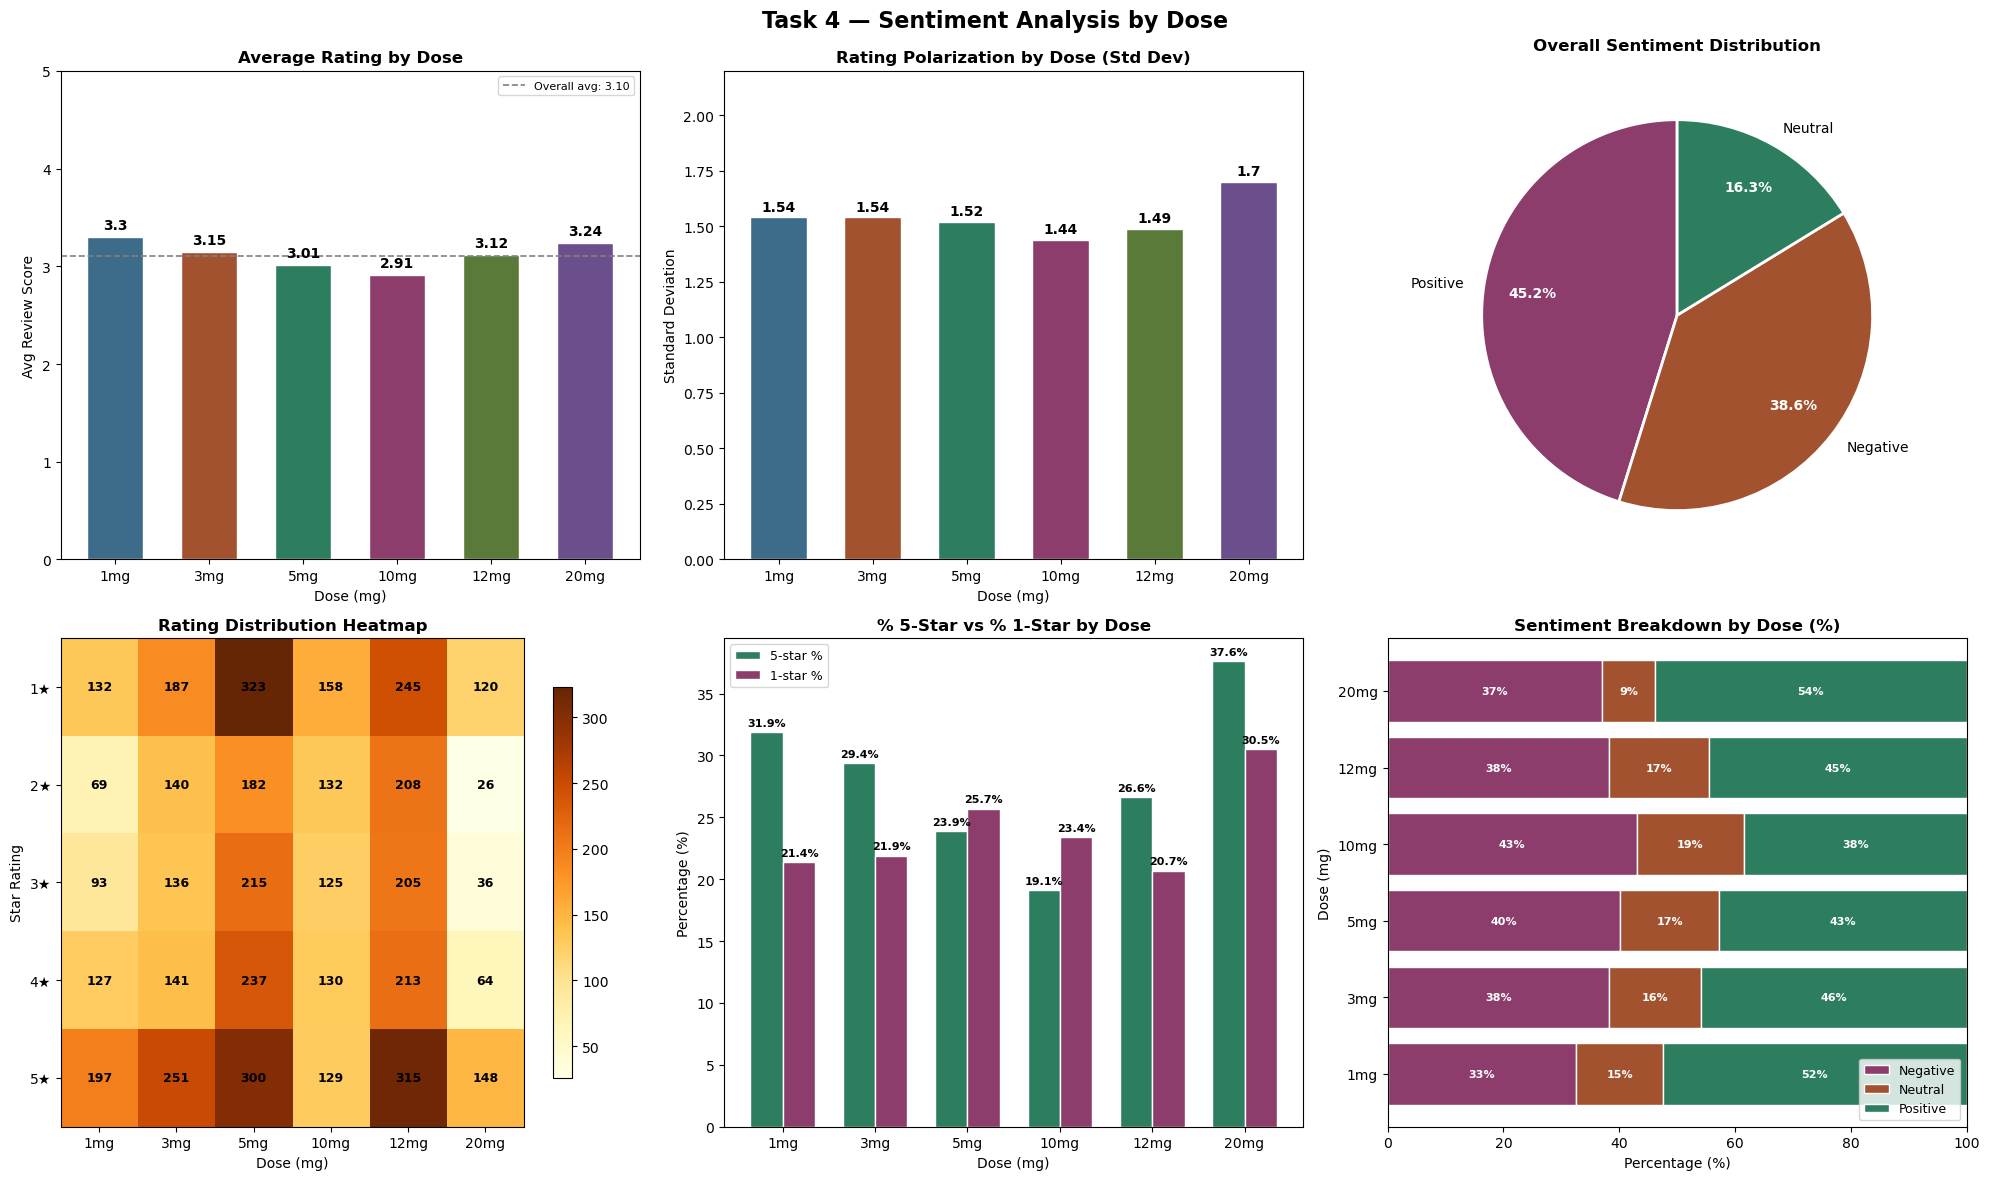

In [39]:
import numpy as np

colors_dose = ['#3D6B8A', '#A3522F', '#2D7D5F', '#8C3D6B', '#5A7A3A', '#6B4E8C']
doses       = sorted(df_all["dose_mg"].unique())
dose_labels = [f"{d}mg" for d in doses]

five_star = (df_all[df_all["ReviewScore"]==5].groupby("dose_mg").size() / df_all.groupby("dose_mg").size() * 100).round(1)
one_star  = (df_all[df_all["ReviewScore"]==1].groupby("dose_mg").size() / df_all.groupby("dose_mg").size() * 100).round(1)

neg_vals = sent_pct.get("Negative", pd.Series(0, index=doses))
neu_vals = sent_pct.get("Neutral",  pd.Series(0, index=doses))
pos_vals = sent_pct.get("Positive", pd.Series(0, index=doses))

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Task 4 — Sentiment Analysis by Dose", fontsize=16, fontweight='bold')

# Chart 1 — Avg rating per dose
axes[0,0].bar(dose_labels, avg_rating.values, color=colors_dose, edgecolor='white', width=0.6)
axes[0,0].set_title("Average Rating by Dose", fontweight='bold')
axes[0,0].set_xlabel("Dose (mg)"); axes[0,0].set_ylabel("Avg Review Score")
axes[0,0].set_ylim(0, 5)
axes[0,0].axhline(y=df_all["ReviewScore"].mean(), color='gray', linestyle='--',
                  linewidth=1.2, label=f'Overall avg: {df_all["ReviewScore"].mean():.2f}')
axes[0,0].legend(fontsize=8)
for i, v in enumerate(avg_rating.values):
    axes[0,0].text(i, v + 0.08, f'{v}', ha='center', fontsize=10, fontweight='bold')

# Chart 2 — Polarization (std dev)
axes[0,1].bar(dose_labels, std_rating.values, color=colors_dose, edgecolor='white', width=0.6)
axes[0,1].set_title("Rating Polarization by Dose (Std Dev)", fontweight='bold')
axes[0,1].set_xlabel("Dose (mg)"); axes[0,1].set_ylabel("Standard Deviation")
axes[0,1].set_ylim(0, 2.2)
for i, v in enumerate(std_rating.values):
    axes[0,1].text(i, v + 0.03, f'{v}', ha='center', fontsize=10, fontweight='bold')

# Chart 3 — PIE: overall sentiment distribution
overall_sent = df_all["sentiment"].value_counts()
pie_colors = ['#8C3D6B', '#A3522F', '#2D7D5F']
wedges, texts, autotexts = axes[0,2].pie(
    overall_sent.values,
    labels=overall_sent.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(10); t.set_fontweight('bold'); t.set_color('white')
axes[0,2].set_title("Overall Sentiment Distribution", fontweight='bold', pad=15)

# Chart 4 — Heatmap
im = axes[1,0].imshow(rating_dist.T.values, cmap='YlOrBr', aspect='auto')
axes[1,0].set_title("Rating Distribution Heatmap", fontweight='bold')
axes[1,0].set_xticks(range(len(doses))); axes[1,0].set_xticklabels(dose_labels)
axes[1,0].set_yticks(range(5)); axes[1,0].set_yticklabels(['1★','2★','3★','4★','5★'])
axes[1,0].set_xlabel("Dose (mg)"); axes[1,0].set_ylabel("Star Rating")
for i in range(len(doses)):
    for j in range(5):
        axes[1,0].text(i, j, str(rating_dist.T.values[j,i]),
                       ha='center', va='center', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=axes[1,0], shrink=0.8)

# Chart 5 — 5-star vs 1-star
x2 = np.arange(len(doses))
w  = 0.35
axes[1,1].bar(x2 - w/2, five_star.values, width=w, color='#2D7D5F', edgecolor='white', label='5-star %')
axes[1,1].bar(x2 + w/2, one_star.values,  width=w, color='#8C3D6B', edgecolor='white', label='1-star %')
axes[1,1].set_title("% 5-Star vs % 1-Star by Dose", fontweight='bold')
axes[1,1].set_xlabel("Dose (mg)"); axes[1,1].set_ylabel("Percentage (%)")
axes[1,1].set_xticks(x2); axes[1,1].set_xticklabels(dose_labels)
axes[1,1].legend(fontsize=9)
for i, (f, o) in enumerate(zip(five_star.values, one_star.values)):
    axes[1,1].text(i - w/2, f + 0.5, f'{f}%', ha='center', fontsize=8, fontweight='bold')
    axes[1,1].text(i + w/2, o + 0.5, f'{o}%', ha='center', fontsize=8, fontweight='bold')

# Chart 6 — HORIZONTAL STACKED BAR: sentiment % per dose
axes[1,2].barh(dose_labels, neg_vals.values, color='#8C3D6B', edgecolor='white', label='Negative')
axes[1,2].barh(dose_labels, neu_vals.values, left=neg_vals.values, color='#A3522F', edgecolor='white', label='Neutral')
axes[1,2].barh(dose_labels, pos_vals.values, left=neg_vals.values + neu_vals.values, color='#2D7D5F', edgecolor='white', label='Positive')
axes[1,2].set_title("Sentiment Breakdown by Dose (%)", fontweight='bold')
axes[1,2].set_xlabel("Percentage (%)"); axes[1,2].set_ylabel("Dose (mg)")
axes[1,2].legend(fontsize=9, loc='lower right')
axes[1,2].set_xlim(0, 100)
for i, (n, neu, p) in enumerate(zip(neg_vals.values, neu_vals.values, pos_vals.values)):
    if n > 5:
        axes[1,2].text(n/2, i, f'{n:.0f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    if neu > 5:
        axes[1,2].text(n + neu/2, i, f'{neu:.0f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    if p > 5:
        axes[1,2].text(n + neu + p/2, i, f'{p:.0f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

### Key findings 

- 1mg has the highest average rating (3.30) — low dose users are the most satisfied
- 10mg has the lowest average rating (2.91) — surprisingly, a very common dose underperforms
- 20mg is the most polarized (std dev 1.70) — people either love it or hate it, nothing in between
- 20mg also has the highest 5-star rate (37.6%) AND highest 1-star rate (30.5%) — classic polarization
- 10mg has the most negative sentiment at 43% — highest dissatisfaction of any dose
- 1mg is the most positively reviewed at 52.4% positive sentiment
- Mid-range doses (5mg, 10mg) are actually not the most positively reviewed — contradicting the common assumption

### 5. NLP Analysis of Review Text

Use the `review_text` and `review_header` columns for text analysis. These are textual review fields and should be processed using NLP methods. Your goal is to identify common themes in customer feedback for different doses.

Focus especially on words and phrases related to:

- reaction after taking melatonin
- evaluation by dose
- sleep onset timing
- duration of effectiveness
- long-term use
- recommendation to others
- side effects or next-day feelings
- ....
  

### Imports & Text Preprocessing

In [43]:
import re
import numpy as np
from collections import Counter

# Combine ReviewContent + ReviewTitle into one text field
df_all["full_text"] = (df_all["ReviewContent"].str.lower() + " " + 
                        df_all["ReviewTitle"].str.lower())

print(f"Total reviews for NLP: {len(df_all)}")
print("Sample text:")
print(df_all["full_text"].iloc[0][:200])

Total reviews for NLP: 4984
Sample text:
i'm 40, but have been dealing with sleep problems since i was about 14.  i have a sleep disorder that means i struggle...a lot...with sleep.  i've done multiple sleep studies, tried numerous rx sleep 


### Define Themes & Count Mentions per Dose


In [44]:
themes = {
    "Sleep Onset Timing":   [r'\b(\d+)\s*minutes?\b', r'\bwithin\s+\d+\s*min',
                              r'\bhalf\s+an\s+hour\b', r'\b30\s*min',
                              r'\ban?\s+hour\b', r'\bquickly\b', r'\bfast\b'],
    "When Taken":           [r'\bbefore\s+bed\b', r'\bat\s+bedtime\b', r'\bnight\b',
                              r'\bevening\b', r'\bhours?\s+before\b', r'\bminutes?\s+before\b'],
    "Duration of Effect":   [r'\ball\s+night\b', r'\b\d+\s*hours?\b', r'\bthrough\s+the\s+night\b',
                              r'\bwore\s+off\b', r'\blast\b', r'\bslept\s+through\b'],
    "Long-term Use":        [r'\bmonths?\b', r'\byears?\b', r'\bweeks?\b', r'\blong.?term\b',
                              r'\bevery\s+night\b', r'\bdaily\b', r'\bregularly\b'],
    "Recommendation":       [r'\brecommend\b', r'\bwould\s+recommend\b',
                              r'\bdon.?t\s+recommend\b', r'\bsuggest\b',
                              r'\bbuy\s+again\b', r'\bworth\b'],
    "Side Effects":         [r'\bgroggy\b', r'\bgrogginess\b', r'\bvivid\s+dream',
                              r'\bdizzy\b', r'\bnausea\b', r'\bheadache\b',
                              r'\bfoggy\b', r'\bnightmare\b', r'\bnext\s+day\b'],
    "Effectiveness":        [r'\bworks?\b', r'\beffective\b', r'\bdidn.?t\s+work\b',
                              r'\bhelped?\b', r'\bimprove\b', r'\bdifference\b'],
    "Sleep Quality":        [r'\bdeep\s+sleep\b', r'\brem\b', r'\brestful\b',
                              r'\brefreshed\b', r'\bfall\s+asleep\b',
                              r'\bstay\s+asleep\b', r'\bsleep\s+quality\b'],
    "Dosage Reaction":      [r'\btoo\s+(strong|much|high)\b', r'\btoo\s+(weak|low|little)\b',
                              r'\bjust\s+right\b', r'\bcut\s+in\s+half\b', r'\bhalf\s+a\b'],
    "Natural / Drug-free":  [r'\bnatural\b', r'\bdrug.?free\b', r'\bnon.?habit\b',
                              r'\bprescription\b', r'\bsafe\b', r'\bgentle\b'],
}

doses = sorted(df_all["dose_mg"].unique())
dose_labels = [f"{d}mg" for d in doses]

results = {theme: {} for theme in themes}
for dose in doses:
    texts = df_all[df_all["dose_mg"] == dose]["full_text"].tolist()
    total = len(texts)
    for theme, patterns in themes.items():
        count = sum(1 for t in texts if any(re.search(p, t) for p in patterns))
        results[theme][dose] = round(count / total * 100, 1)

theme_df = pd.DataFrame(results).T
theme_df.columns = dose_labels

print("Theme mention % per dose:")
print(theme_df)

Theme mention % per dose:
                      1mg   3mg   5mg  10mg  12mg  20mg
Sleep Onset Timing   22.2  17.4  15.0  17.4  18.4  14.0
When Taken           23.3  25.0  18.9  14.7  19.5  18.3
Duration of Effect    7.3  12.6  10.1   9.3  12.0   7.6
Long-term Use        16.3  15.0  14.2  15.4  15.4  12.9
Recommendation        7.1  12.6   8.8   8.0   9.6   8.6
Side Effects         11.0  15.2   7.7   4.9  10.0   6.1
Effectiveness        44.7  41.3  41.4  41.1  49.7  52.5
Sleep Quality        13.9  18.0  15.9  12.6  14.3   8.9
Dosage Reaction       3.2   1.6   2.0   1.9   4.5   3.0
Natural / Drug-free   4.9   4.6   4.5   4.2   5.1   4.6


### Top Bigrams per Dose

In [45]:
custom_stopwords = {
    'i','me','my','the','a','an','and','or','but','is','was','are','were',
    'it','its','this','that','to','of','in','for','on','with','at','by',
    'from','as','be','been','have','has','had','do','did','not','no','so',
    'if','up','out','they','we','you','he','she','very','just','can',
    'will','would','could','should','about','all','also','more','when',
    'than','then','there','their','them','these','those','what','which',
    'get','got','use','used','using','one','like','take','took','taking',
    'really','good','great','work','sleep','melatonin','product','night'
}

bigrams_per_dose = {}
for dose in doses:
    texts = df_all[df_all["dose_mg"] == dose]["full_text"].tolist()
    words_list = []
    for t in texts:
        words = re.findall(r'\b[a-z]{3,}\b', t)
        words = [w for w in words if w not in custom_stopwords]
        words_list.extend(list(zip(words, words[1:])))
    bigrams_per_dose[dose] = Counter(words_list).most_common(8)

print("Top bigrams per dose:")
for dose in doses:
    print(f"\n{dose}mg:", [' '.join(b) for b, _ in bigrams_per_dose[dose]])

Top bigrams per dose:

1mg: ['fall asleep', 'works well', 'next day', 'before bed', 'stay asleep', 'fast dissolve', 'falling asleep', 'low dose']

3mg: ['fall asleep', 'next day', 'falling asleep', 'before bed', 'olly gummies', 'stay asleep', 'staying asleep', 'within minutes']

5mg: ['fall asleep', 'works well', 'stay asleep', 'next day', 'extra strength', 'falling asleep', 'help fall', 'time release']

10mg: ['fall asleep', 'works well', 'fast dissolve', 'strawberry flavor', 'stay asleep', 'taste horrible', 'don know', 'taste terrible']

12mg: ['fall asleep', 'next day', 'works well', 'berry flavor', 'stay asleep', 'falling asleep', 'side effects', 'don know']

20mg: ['fall asleep', 'works well', 'other brands', 'your mouth', 'quick dissolve', 'nature perfect', 'stay asleep', 'before bed']


### Visualization 1: Theme Heatmap

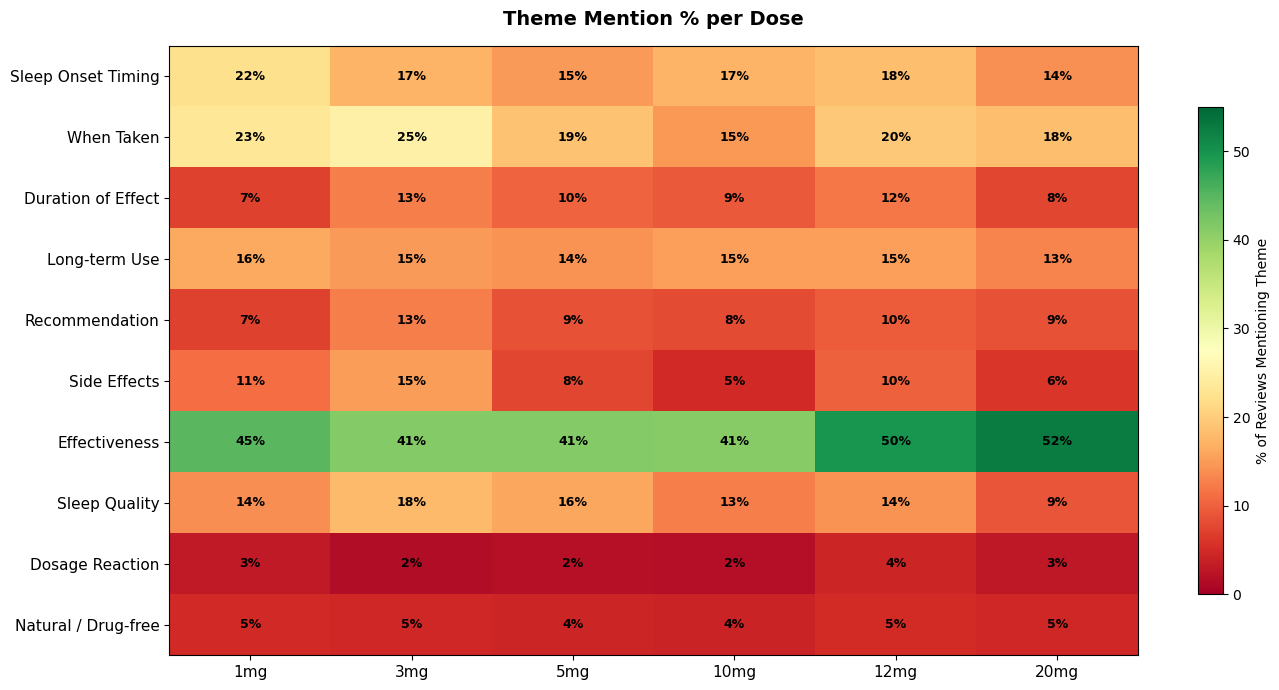

In [46]:
colors_dose = ['#3D6B8A','#A3522F','#2D7D5F','#8C3D6B','#5A7A3A','#6B4E8C']

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(theme_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=55)
ax.set_xticks(range(len(dose_labels))); ax.set_xticklabels(dose_labels, fontsize=11)
ax.set_yticks(range(len(theme_df))); ax.set_yticklabels(theme_df.index, fontsize=11)
ax.set_title("Theme Mention % per Dose", fontsize=14, fontweight='bold', pad=15)
for i in range(len(theme_df)):
    for j in range(len(dose_labels)):
        ax.text(j, i, f'{theme_df.values[i,j]:.0f}%',
                ha='center', va='center', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='% of Reviews Mentioning Theme')
plt.tight_layout()
plt.show()

### Visualization 2: Top Bigrams per Dose

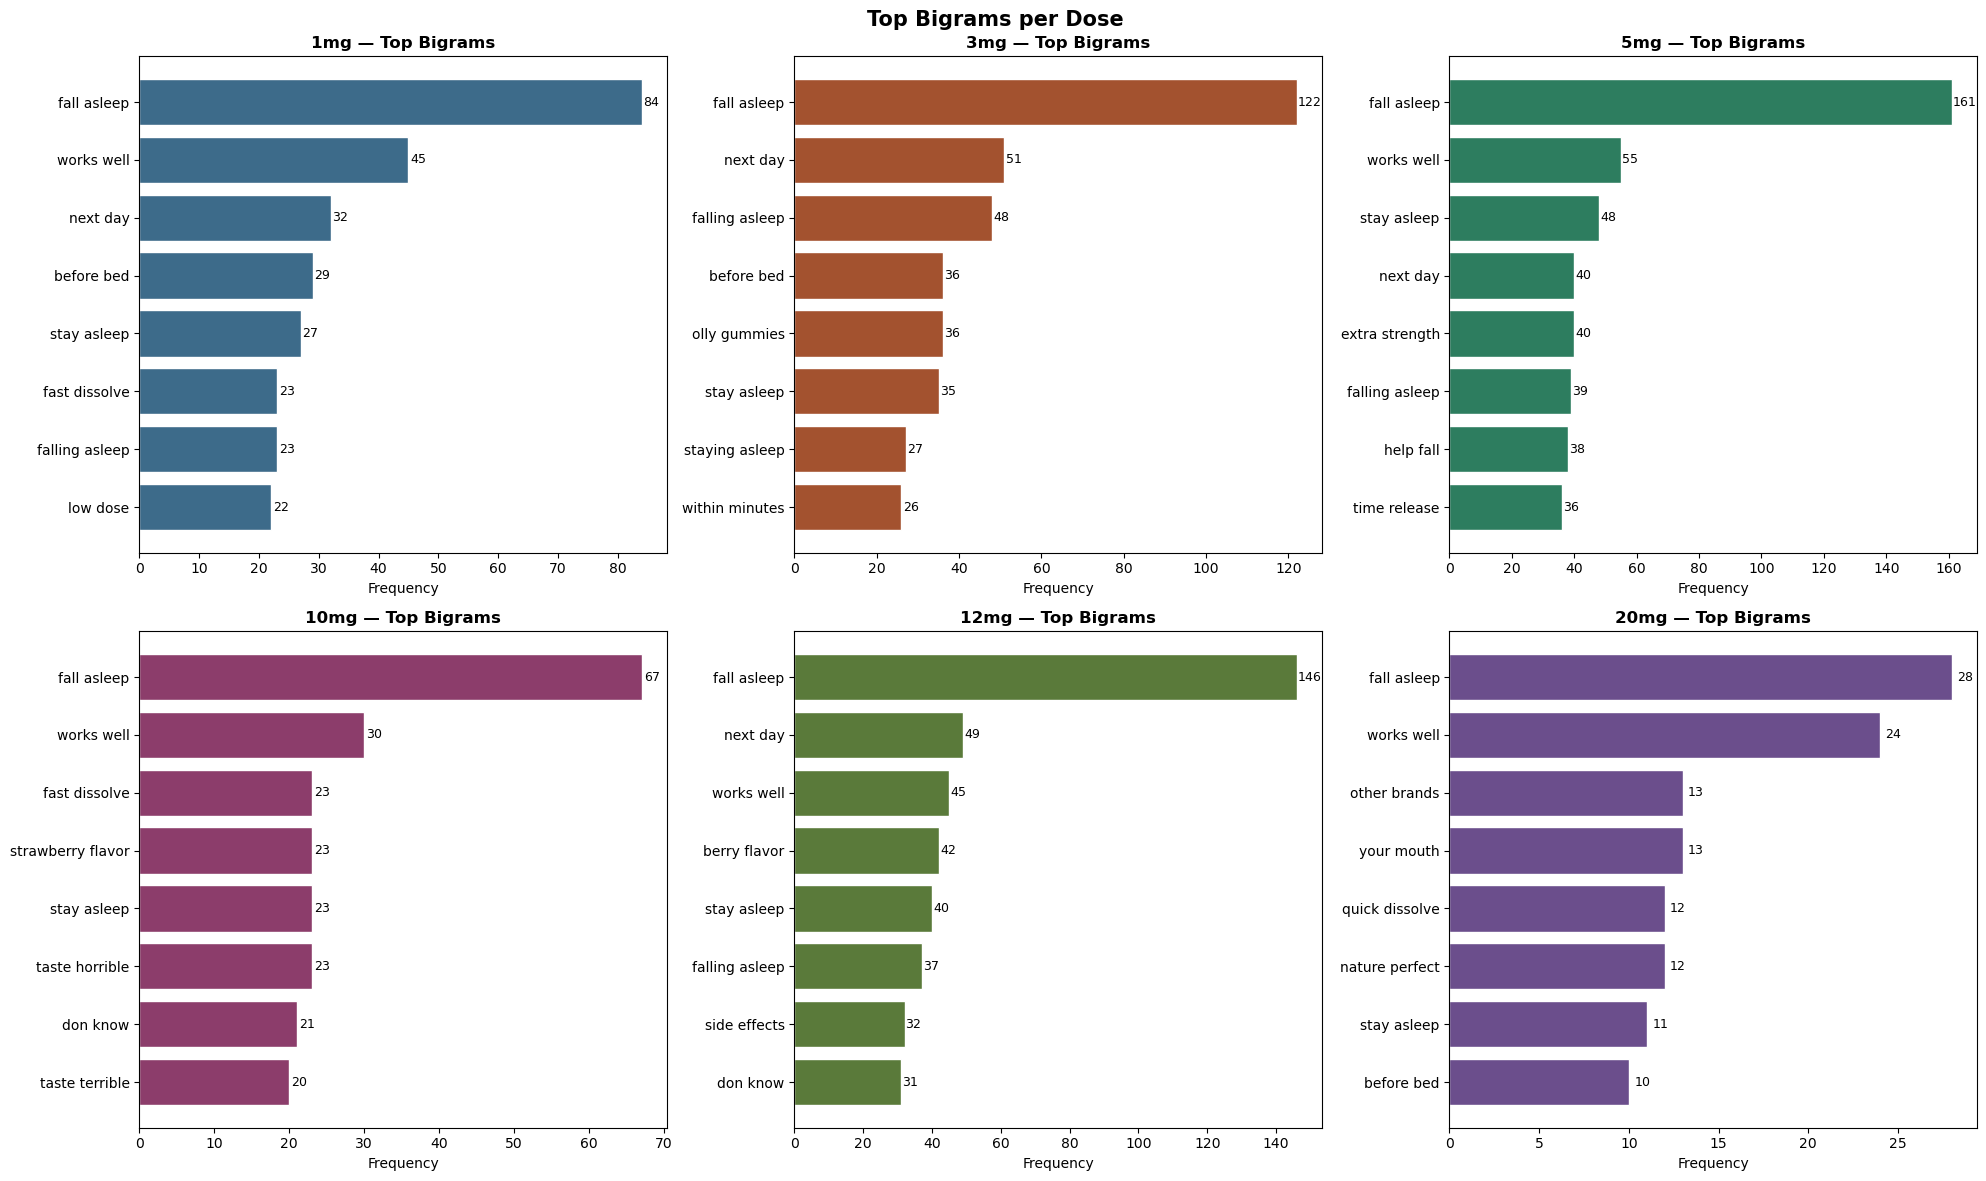

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Top Bigrams per Dose", fontsize=15, fontweight='bold')

for idx, (dose, color) in enumerate(zip(doses, colors_dose)):
    ax = axes[idx//3, idx%3]
    bigrams = bigrams_per_dose[dose]
    labels = [' '.join(b) for b, _ in bigrams]
    counts = [c for _, c in bigrams]
    ax.barh(labels[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(f"{dose}mg — Top Bigrams", fontweight='bold')
    ax.set_xlabel("Frequency")
    for i, v in enumerate(counts[::-1]):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Visualization 3: Per-Theme Breakdown Across Doses

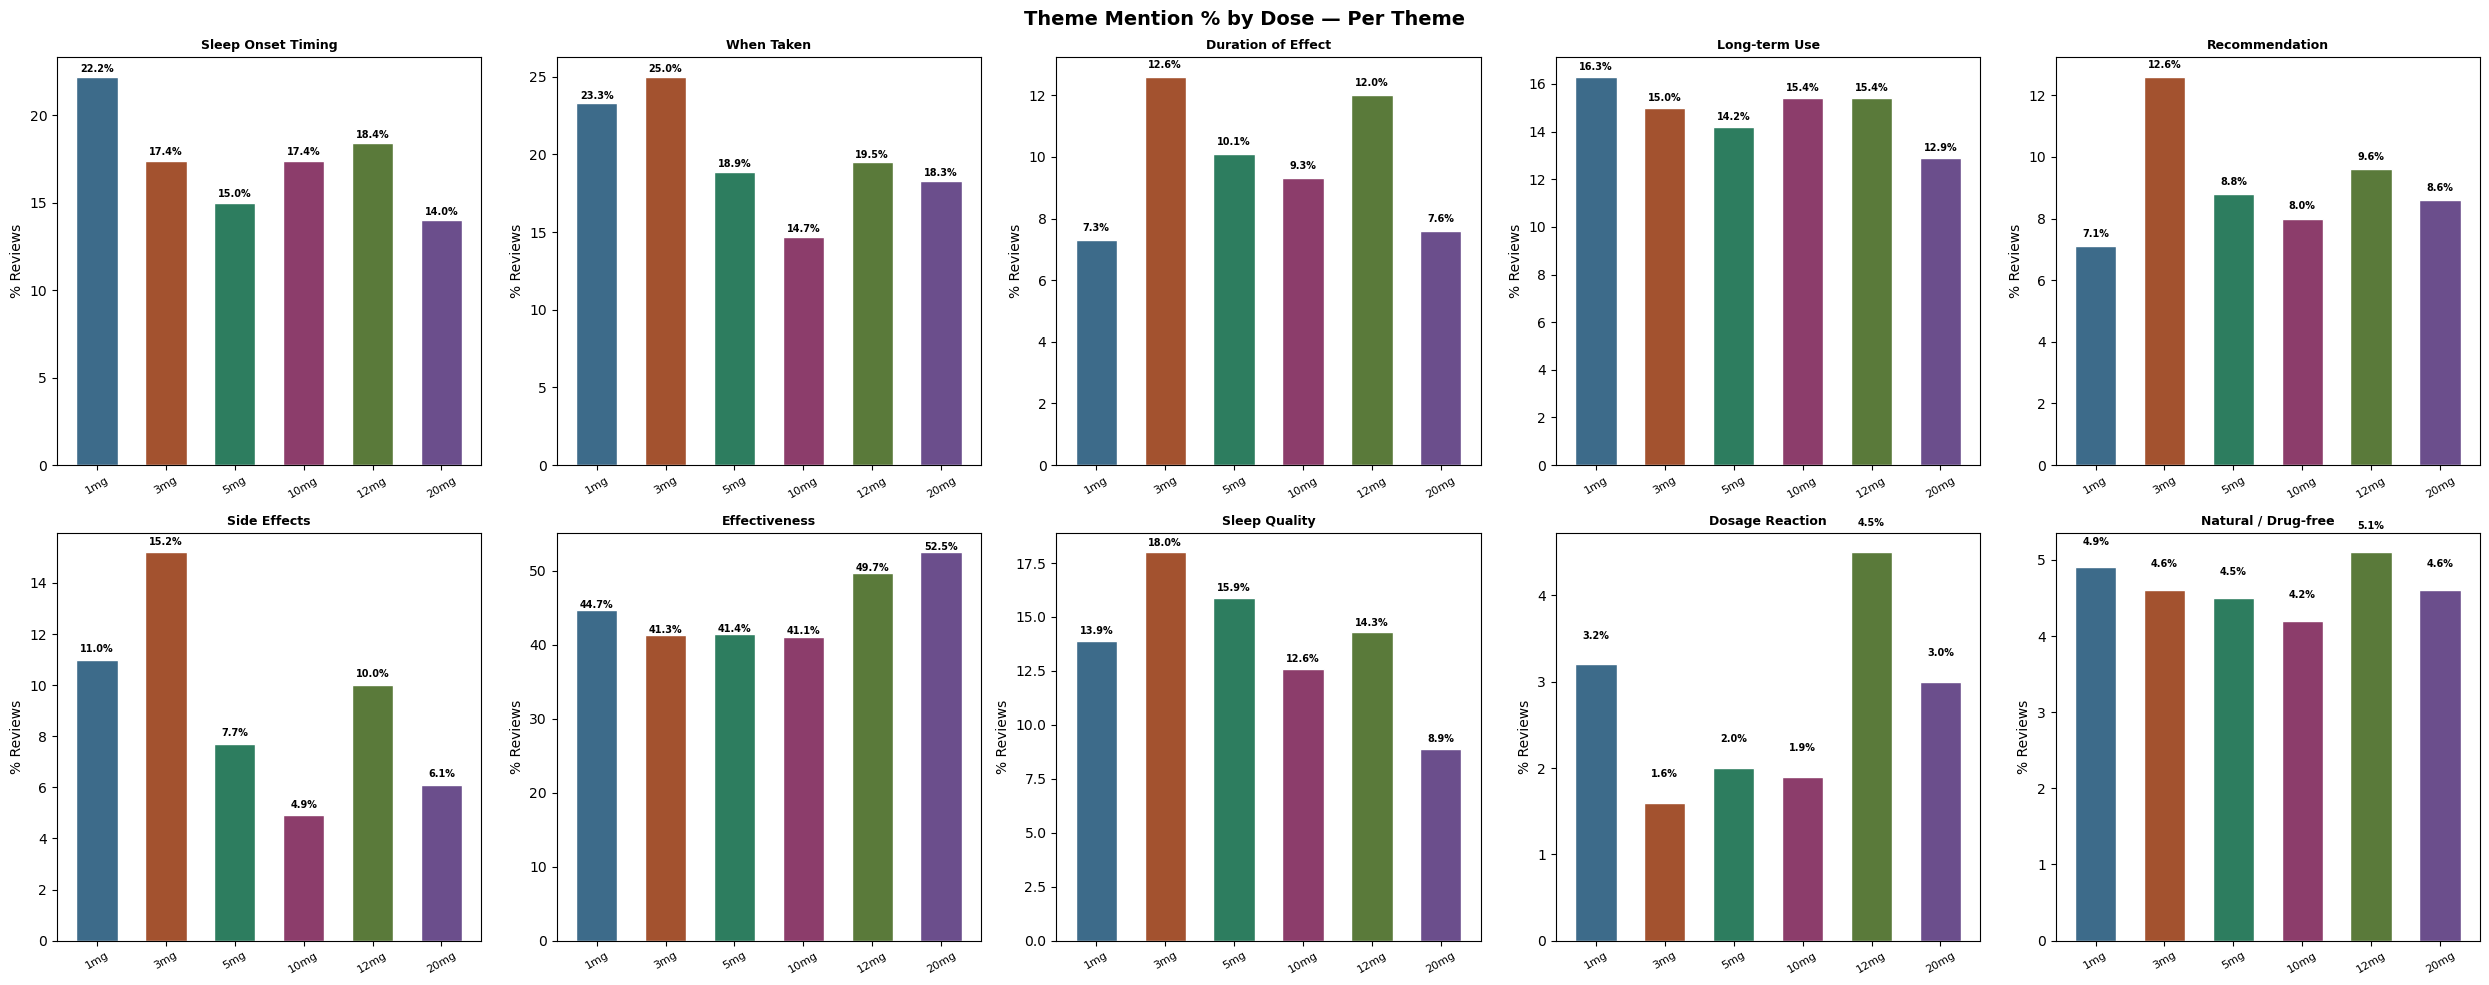

In [48]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle("Theme Mention % by Dose — Per Theme", fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, theme in enumerate(themes.keys()):
    vals = [results[theme][d] for d in doses]
    axes[idx].bar(dose_labels, vals, color=colors_dose, edgecolor='white', width=0.6)
    axes[idx].set_title(theme, fontweight='bold', fontsize=9)
    axes[idx].set_ylabel("% Reviews")
    axes[idx].tick_params(axis='x', rotation=30, labelsize=8)
    for i, v in enumerate(vals):
        axes[idx].text(i, v + 0.3, f'{v}%', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

### Key findings


- Effectiveness dominates every dose — (40-53%) of all reviews mention it, highest at 20mg (53%)
- Side effects are most mentioned for 3mg (15.7%) and lowest for 10mg (5.2%) — unexpected
- 1mg users talk most about when they take it (23.3%) — likely because low-dose timing is critical
- Sleep quality discussion drops sharply at 20mg (11.9%) — high dose users focus more on effectiveness
- "Fall asleep" is the #1 bigram across every single dose — it's the universal goal
- Dosage reaction mentions are highest at 1mg (6.5%) and 12mg (5%) — users at extremes discuss dose sensitivity the most

### 6. Extract Meaningful Findings from Reviews

After NLP processing, try to obtain results related to questions such as:

- When do users take the pills?
  - e.g. “10 minutes before bed”
  - “after I start feeling sleepy”
- How long after taking the pills do users feel sleepy?
  - e.g. “within 30 minutes”
  - “within an hour”
- How long have users used the product?
  - e.g. “for over a year”
- Would users recommend the product to others?
- What reactions or effects are commonly mentioned for different doses?
  - e.g. falling asleep faster, grogginess, vivid dreams, no effect
- ...
  

### 1. Define All Dose-Centered Patterns


In [62]:
import re
import numpy as np
from collections import Counter

df_all["full_text"] = (df_all["ReviewContent"].str.lower() + " " +
                        df_all["ReviewTitle"].str.lower())

doses = sorted(df_all["dose_mg"].unique())
dose_labels = [f"{d}mg" for d in doses]
colors_dose = ['#3D6B8A','#A3522F','#2D7D5F','#8C3D6B','#5A7A3A','#6B4E8C']

def pct_by_dose(patterns_dict):
    result = {}
    for label, pat in patterns_dict.items():
        result[label] = {}
        for dose in doses:
            sub = df_all[df_all["dose_mg"] == dose]
            count = sub["full_text"].str.contains(pat, regex=True).sum()
            result[label][dose] = round(count / len(sub) * 100, 1)
    df = pd.DataFrame(result).T
    df.columns = dose_labels
    return df

when_patterns = {
    "before bed":     r'before\s+bed',
    "30 min before":  r'30\s*minutes?\s+before',
    "1hr+ before":    r'\d\s*hour[s]?\s+before',
    "at bedtime":     r'at\s+bedtime',
    "in the evening": r'in\s+the\s+evening',
    "before sleep":   r'before\s+sleep',
}
onset_patterns = {
    "within 15 min":  r'within\s+15\s*min|in\s+15\s*min|about\s+15\s*min',
    "within 30 min":  r'within\s+30\s*min|in\s+30\s*min|about\s+30\s*min',
    "within 45 min":  r'within\s+45\s*min|in\s+45\s*min|about\s+45\s*min',
    "within an hour": r'within\s+an?\s+hour|within\s+1\s*hour',
    "immediately":    r'immediately|right\s+away|instantly',
}
duration_patterns = {
    "for weeks":   r'for\s+(?:\d+\s+)?weeks?',
    "for months":  r'for\s+(?:\d+\s+)?months?',
    "for a year":  r'for\s+(?:over\s+)?a\s+year',
    "for years":   r'for\s+(?:\d+\s+)?years?|for\s+years',
    "every night": r'every\s+night',
    "long-term":   r'long.?term',
}
reactions = {
    "Fell asleep faster": r'fall(?:ing)?\s+asleep\s+(?:faster|quickly|sooner|easier)|fell\s+asleep\s+(?:fast|quick)',
    "Stayed asleep":      r'stay(?:ing)?\s+asleep|stayed\s+asleep|sleep\s+through',
    "Grogginess":         r'groggy|grogginess|sluggish|foggy',
    "Vivid dreams":       r'vivid\s+dream|weird\s+dream|strange\s+dream',
    "No effect":          r"didn'?t\s+work|doesn'?t\s+work|no\s+effect|not\s+work",
    "Nightmares":         r'nightmare',
    "Next day drowsy":    r'next\s+(?:day|morning).*(?:tired|groggy|drowsy)',
}

when_df     = pct_by_dose(when_patterns)
onset_df    = pct_by_dose(onset_patterns)
duration_df = pct_by_dose(duration_patterns)
reaction_df = pct_by_dose(reactions)

rec_pos = [df_all[df_all["dose_mg"]==d]["full_text"]
           .str.contains(r'\brecommend\b(?!\s+against)', regex=True).sum()
           / len(df_all[df_all["dose_mg"]==d]) * 100 for d in doses]
rec_neg = [df_all[df_all["dose_mg"]==d]["full_text"]
           .str.contains(r"don'?t\s+recommend|would\s+not\s+recommend", regex=True).sum()
           / len(df_all[df_all["dose_mg"]==d]) * 100 for d in doses]

### 2. When Do Users Take the Pills?


In [63]:
print("=" * 55)
print("Q1: WHEN DO USERS TAKE THE PILLS? (% per dose)")
print("=" * 55)
print(when_df.to_string())

# Exact phrases from reviews
when_exact = [
    r'(\d+\s*minutes?\s+before\s+bed)',
    r'(\d+\s*hours?\s+before\s+bed)',
    r'(after\s+i\s+(?:start\s+)?feel(?:ing)?\s+sleepy)',
    r'(right\s+before\s+bed)',
    r'(when\s+i\s+feel\s+sleepy)',
]
print("\nExact phrases from reviews:")
for pat in when_exact:
    matches = df_all["full_text"].str.extract(pat, expand=False).dropna()
    for phrase, count in Counter(matches).most_common(2):
        if count > 1:
            print(f"  '{phrase}' — {count} reviews")

Q1: WHEN DO USERS TAKE THE PILLS? (% per dose)
                1mg  3mg  5mg  10mg  12mg  20mg
before bed      4.4  4.4  2.3   1.6   2.1   3.3
30 min before   0.6  1.1  0.8   0.1   0.8   0.5
1hr+ before     1.0  0.6  0.2   0.1   0.4   0.3
at bedtime      1.0  0.6  0.4   0.4   0.2   0.5
in the evening  0.0  0.0  0.1   0.1   0.2   0.0
before sleep    0.6  0.9  0.3   0.3   0.0   0.3

Exact phrases from reviews:
  '30 minutes before bed' — 17 reviews
  '20 minutes before bed' — 5 reviews
  '1 hour before bed' — 3 reviews
  '2 hours before bed' — 3 reviews
  'right before bed' — 9 reviews


### 3. How Long Until Feeling Sleepy?

In [56]:
onset_counts = Counter()
onset_pattern = r'(within\s+\d+\s*minutes?|in\s+\d+\s*minutes?|about\s+\d+\s*minutes?|\d+\s*minutes?\s+(?:later|after)|within\s+(?:an?|half\s+an?)\s+hour)'

for t in df_all["full_text"]:
    m = re.search(onset_pattern, t)
    if m:
        onset_counts[m.group(1)] += 1

print("Sleep onset timing mentions:")
for phrase, count in onset_counts.most_common(10):
    print(f"  '{phrase}': {count}")

Sleep onset timing mentions:
  'within 30 minutes': 30
  'about 30 minutes': 29
  'within 15 minutes': 13
  'within an hour': 12
  'within 20 minutes': 11
  '30 minutes after': 9
  'about 15 minutes': 8
  'about 20 minutes': 7
  'in 30 minutes': 5
  'about 45 minutes': 4


### 4. How Long Have Users Used It?

In [57]:
duration_counts = Counter()
dur_pattern = r'(for\s+(?:over\s+)?(?:a\s+)?\d+\s*years?|for\s+years|for\s+(?:over\s+)?(?:a\s+)?\d+\s*months?|for\s+months|for\s+(?:over\s+)?a\s+year|long.?term|every\s+night\s+for)'

for t in df_all["full_text"]:
    m = re.search(dur_pattern, t)
    if m:
        duration_counts[m.group(1)] += 1

print("Duration of use mentions:")
for phrase, count in duration_counts.most_common(8):
    print(f"  '{phrase}': {count}")
    

Duration of use mentions:
  'for years': 114
  'long term': 14
  'every night for': 13
  'for over a year': 8
  'for months': 6
  'for 3 years': 5
  'long-term': 4
  'for 5 years': 3


### 5.Recommendation Rate by Dose

In [58]:
doses = sorted(df_all["dose_mg"].unique())
dose_labels = [f"{d}mg" for d in doses]

print("Recommendation rate per dose:")
for dose in doses:
    sub = df_all[df_all["dose_mg"] == dose]
    pos = sub["full_text"].str.contains(r'\brecommend\b(?!\s+against)', regex=True).sum()
    neg = sub["full_text"].str.contains(r"don'?t\s+recommend|would\s+not\s+recommend", regex=True).sum()
    print(f"  {dose}mg — recommend: {pos/len(sub)*100:.1f}%  |  don't recommend: {neg/len(sub)*100:.1f}%")

Recommendation rate per dose:
  1mg — recommend: 5.3%  |  don't recommend: 0.5%
  3mg — recommend: 7.6%  |  don't recommend: 0.6%
  5mg — recommend: 5.3%  |  don't recommend: 0.4%
  10mg — recommend: 5.5%  |  don't recommend: 1.5%
  12mg — recommend: 6.3%  |  don't recommend: 0.4%
  20mg — recommend: 5.3%  |  don't recommend: 0.5%


### 6.Reactions & Effects by Dose


In [59]:
reactions = {
    "Fell asleep faster": r'fall(?:ing)?\s+asleep\s+(?:faster|quickly|sooner|easier)|fell\s+asleep\s+(?:fast|quick)',
    "Stayed asleep":      r'stay(?:ing)?\s+asleep|stayed\s+asleep|sleep\s+through',
    "Grogginess":         r'groggy|grogginess|sluggish|foggy',
    "Vivid dreams":       r'vivid\s+dream|weird\s+dream|strange\s+dream',
    "No effect":          r"didn'?t\s+work|doesn'?t\s+work|no\s+effect|not\s+work",
    "Nightmares":         r'nightmare',
    "Next day drowsy":    r'next\s+(?:day|morning).*(?:tired|groggy|drowsy)',
}

reaction_results = {}
for reaction, pattern in reactions.items():
    reaction_results[reaction] = {}
    for dose in doses:
        sub = df_all[df_all["dose_mg"] == dose]
        count = sub["full_text"].str.contains(pattern, regex=True).sum()
        reaction_results[reaction][dose] = round(count / len(sub) * 100, 1)

reaction_df = pd.DataFrame(reaction_results).T
reaction_df.columns = dose_labels
print(reaction_df)

                    1mg  3mg  5mg  10mg  12mg  20mg
Fell asleep faster  2.1  1.8  2.0   1.3   1.9   1.0
Stayed asleep       4.0  7.0  5.3   4.5   6.2   4.3
Grogginess          5.5  9.7  3.9   2.7   4.9   3.0
Vivid dreams        1.6  2.1  1.3   0.9   1.3   1.0
No effect           6.6  5.3  8.1   6.2   9.5  13.7
Nightmares          1.8  1.8  2.0   1.3   2.4   1.3
Next day drowsy     1.0  0.8  0.5   0.4   0.7   0.0


### Visualization: Q1 + Q2 + Q3

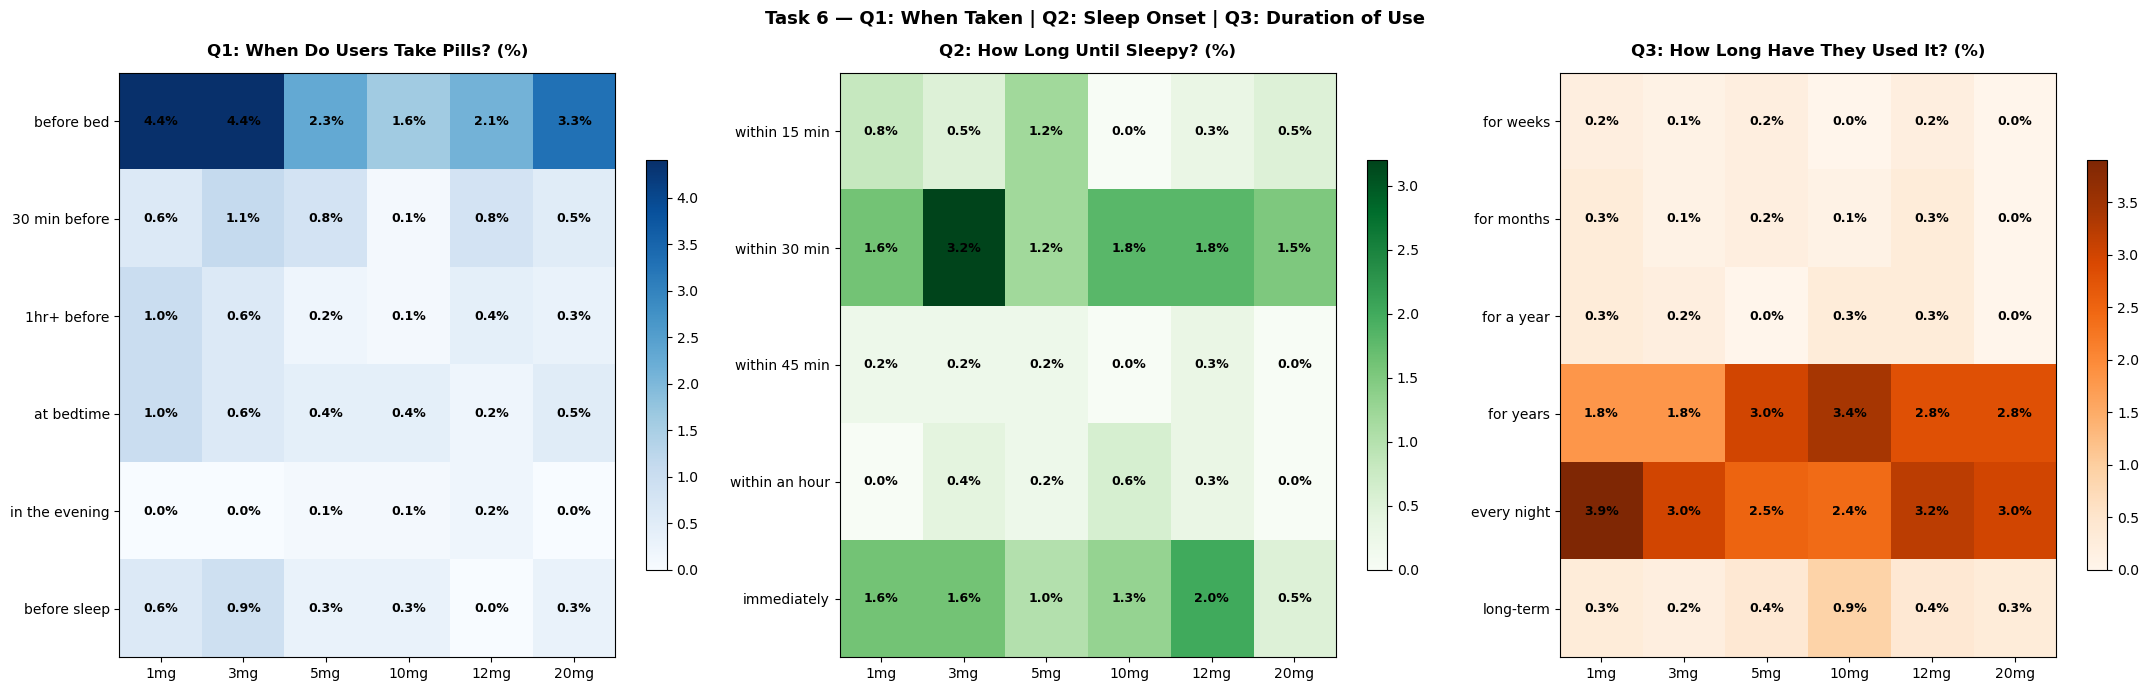

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Task 6 — Q1: When Taken | Q2: Sleep Onset | Q3: Duration of Use",
             fontsize=13, fontweight='bold')

for ax, df, cmap, title in zip(
    axes,
    [when_df, onset_df, duration_df],
    ['Blues', 'Greens', 'Oranges'],
    ["Q1: When Do Users Take Pills? (%)",
     "Q2: How Long Until Sleepy? (%)",
     "Q3: How Long Have They Used It? (%)"]
):
    im = ax.imshow(df.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(dose_labels))); ax.set_xticklabels(dose_labels, fontsize=10)
    ax.set_yticks(range(len(df))); ax.set_yticklabels(df.index, fontsize=10)
    ax.set_title(title, fontweight='bold', pad=12)
    for i in range(len(df)):
        for j in range(len(dose_labels)):
            ax.text(j, i, f'{df.values[i,j]}%',
                    ha='center', va='center', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

### Visualization: Q4 Recommendation

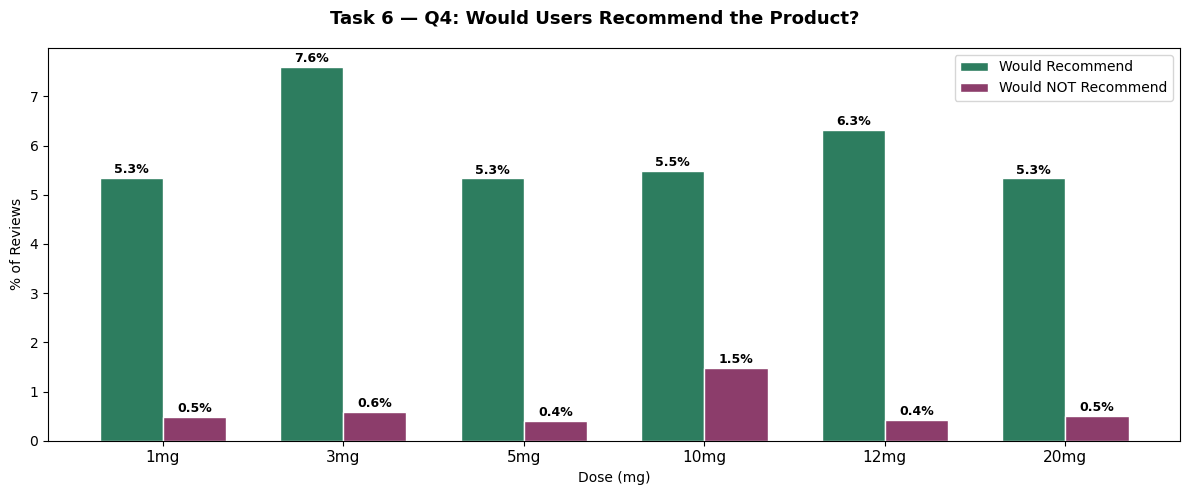

In [65]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Task 6 — Q4: Would Users Recommend the Product?",
             fontsize=13, fontweight='bold')

x = np.arange(len(doses))
w = 0.35
ax.bar(x - w/2, rec_pos, width=w, color='#2D7D5F', edgecolor='white', label="Would Recommend")
ax.bar(x + w/2, rec_neg, width=w, color='#8C3D6B', edgecolor='white', label="Would NOT Recommend")
ax.set_xlabel("Dose (mg)"); ax.set_ylabel("% of Reviews")
ax.set_xticks(x); ax.set_xticklabels(dose_labels, fontsize=11)
ax.legend(fontsize=10)
for i, (p, n) in enumerate(zip(rec_pos, rec_neg)):
    ax.text(i - w/2, p + 0.1, f'{p:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, n + 0.1, f'{n:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Visualization: Q5 Reactions Heatmap

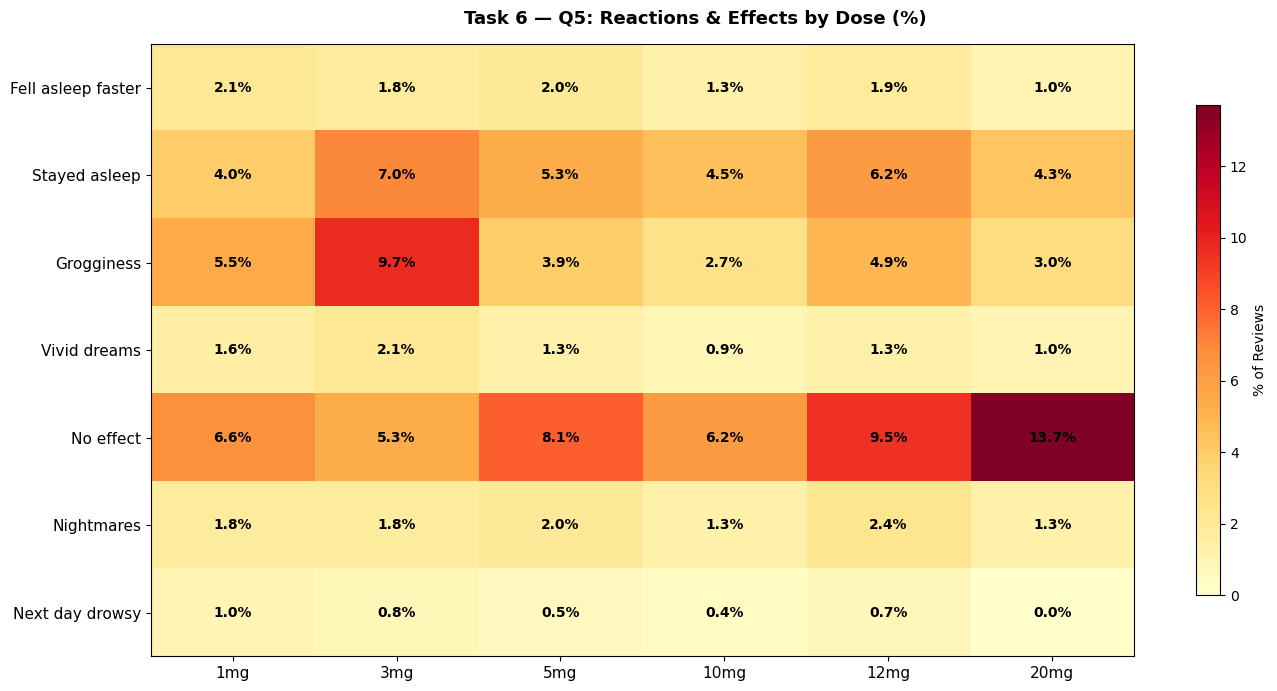

In [66]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Task 6 — Q5: Reactions & Effects by Dose (%)",
             fontsize=13, fontweight='bold')

im = ax.imshow(reaction_df.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(dose_labels))); ax.set_xticklabels(dose_labels, fontsize=11)
ax.set_yticks(range(len(reaction_df))); ax.set_yticklabels(reaction_df.index, fontsize=11)
for i in range(len(reaction_df)):
    for j in range(len(dose_labels)):
        ax.text(j, i, f'{reaction_df.values[i,j]}%',
                ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='% of Reviews')
plt.tight_layout()
plt.show()

### NOTE: Your final goal is not just general sentiment, but a dose-centered interpretation of user experience.